# Breast Cancer Wisconsin (Diagnostic)

Il notebook analizza il dataset *Breast Cancer Wisconsin (Diagnostic)* tramite un problema di **classificazione binaria supervisionata** attraverso l'utilizzo di quattro modelli differenti:
- Logistic Regression
- Linear Discriminant Analysis
- Support Vector Machine (con kernel RBF)
- Random Forest

## Setup e configurazione dell'ambiente

In [32]:
#Installazione delle dipendenze non standard (ucimlrepo per il dataset UCI, shap per la spiegabilita)
!pip install ucimlrepo shap --quiet

In [33]:
#Librerie per manipolazione dati e calcolo numerico
import numpy as np
import pandas as pd

#Librerie per visualizzazione
import matplotlib.pyplot as plt
import seaborn as sns

#Recupero del dataset dal repository UCI
from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, validation_curve, RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, ConfusionMatrixDisplay, roc_auc_score

#Import dei modelli
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

#Spiegabilità
import shap

#Nasconde i warnings
import warnings
warnings.filterwarnings("ignore")

#Seme globale per la riproducibilita
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Ambiente configurato correttamente.")

Ambiente configurato correttamente.


## Caricamento ed encoding della classe positiva

In [34]:
#Caricamento del dataset
bcwd = fetch_ucirepo(id = 17)

#Separazione di feature (X) e target (y)
X = bcwd.data.features
y_raw = bcwd.data.targets
target_column = y_raw.columns[0]

#Ispezione delle dimensioni
print(f"\nNomi delle {len(X.columns)} feature:\n{list(X.columns)}")
print(f"\nValori unici del target: {list(y_raw[target_column].unique())}")


Nomi delle 30 feature:
['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']

Valori unici del target: ['M', 'B']


Il dataset è composto da **569 osservazioni**, caratterizzate da un **target binario** e **30 feature** calcolate da immagini digitalizzate di agoaspirati mammari (FNA). 

Le feature derivano da 10 grandezze del nucleo cellulare, per ciascuna delle quali sono riportate tre statistiche:
- valore **medio** (*mean*)
- **errore standard** (*standard error*)
- valore **peggiore** (*worst*)

I valori originali del target, 'M' (Maligno) e 'B' (Benigno), verranno trasformati rispettivamente in 1 e 0. Questa codifica è fondamentale perchè, se la invertissimo, metriche come la Sensibilità (Recall) valuterebbero la capacità di individuare i casi benigni, distorcendo l'obiettivo di minimizzare i falsi negativi sui tumori maligni.

In [35]:
display(X.head())
display(y_raw.head())

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,Diagnosis
0,M
1,M
2,M
3,M
4,M


## Analisi Esplorativa dei Dati

In [36]:
#Codifica M -> 1, B -> 0
y = y_raw[target_column].map({"M": 1, "B": 0}).astype(int)

#Verifica di valori mancanti
print(f"Valori mancanti nelle feature: {int(X.isnull().sum().sum())}")
print(f"Valori mancanti nel target: {int(y.isnull().sum())}")

Valori mancanti nelle feature: 0
Valori mancanti nel target: 0


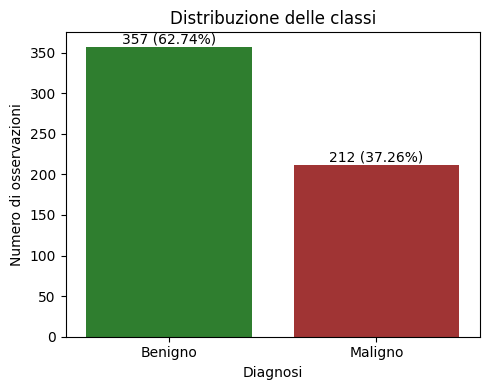

In [37]:
#Visualizzazione della distribuzione e delle proporzioni
fig, ax = plt.subplots(figsize = (5, 4))
diagnosi = y.map({0: "Benigno", 1: "Maligno"})

#Creazione del grafico
sns.countplot(x = diagnosi, order = ["Benigno", "Maligno"], hue = diagnosi, palette = {"Benigno": "forestgreen", "Maligno": "firebrick"}, legend = False, ax = ax)
ax.set(title = "Distribuzione delle classi", xlabel = "Diagnosi", ylabel = "Numero di osservazioni")

#Annotazione con conteggio e percentuale
for p in ax.patches:
    c = int(p.get_height())
    ax.annotate(f"{c} ({c / len(y):.2%})", (p.get_x() + p.get_width() / 2, c), ha = "center", va = "bottom")

plt.tight_layout()
plt.show()

Questo sbilanciamento (63% vs 37%) rende l'accuratezza globale una metrica ingannevole poichè se un modello predicesse banalmente "Tutti Benigni", avrebbe comunque un'accuratezza del 63%, ma fallirebbe miseramente il suo scopo.

In [38]:
X.describe().T[["mean", "std", "min", "max"]].head(10)

,mean,std,min,max
radius1,14.127292,3.524049,6.98100,28.11000
texture1,19.289649,4.301036,9.71000,39.28000
perimeter1,91.969033,24.298981,43.79000,188.50000
area1,654.889104,351.914129,143.50000,2501.00000
smoothness1,0.096360,0.014064,0.05263,0.16340
compactness1,0.104341,0.052813,0.01938,0.34540
concavity1,0.088799,0.079720,0.00000,0.42680
concave_points1,0.048919,0.038803,0.00000,0.20120
symmetry1,0.181162,0.027414,0.10600,0.30400
fractal_dimension1,0.062798,0.007060,0.04996,0.09744


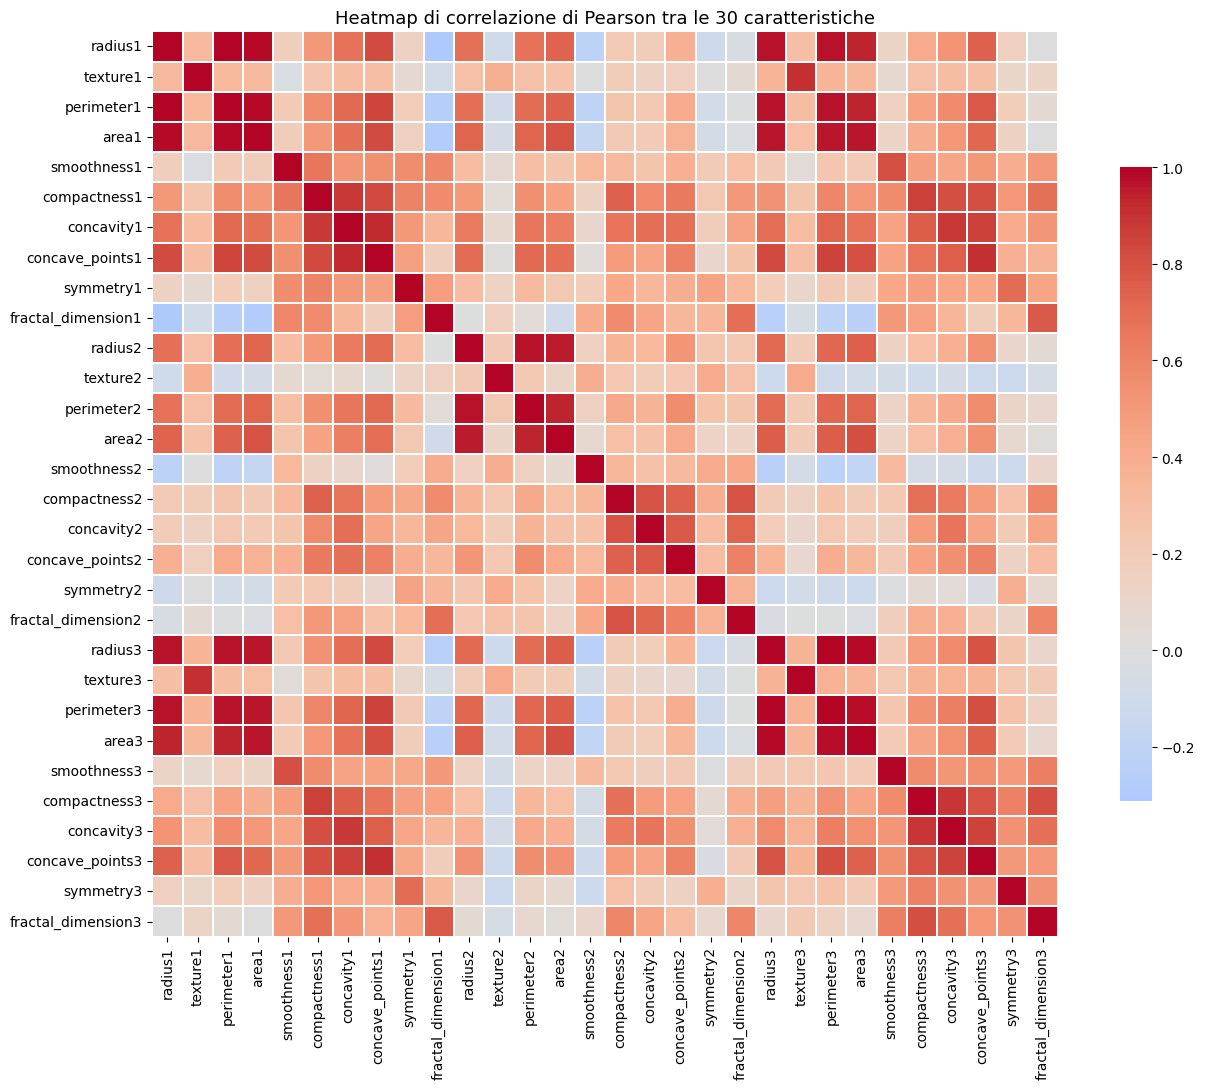

In [39]:
#Matrice di correlazione di Pearson tra le 30 caratteristiche
corr_matrix = X.corr()

fig, ax = plt.subplots(figsize = (14, 11))
sns.heatmap(corr_matrix, cmap = "coolwarm", center = 0, square = True, linewidths = 0.3, cbar_kws = {"shrink": 0.7}, ax = ax)
ax.set_title("Heatmap di correlazione di Pearson tra le 30 caratteristiche", fontsize = 13)
plt.tight_layout()
plt.show()

Emergono diversi blocchi rossi (correlazione ~1) tra grandezze geometricamente legate (`radius`, `perimeter` e `area` sono quasi ridondanti) e ciascuna grandezza è fortemente correlata con la propria versione *worst*. 

Questa **multicollinearità** ha due conseguenze:
- rende instabile e di difficile interpretazione la magnitudine dei singoli coefficienti dei modelli lineari;
- suggerisce che la dimensionalità *effettiva* del problema è ben inferiore a 30.

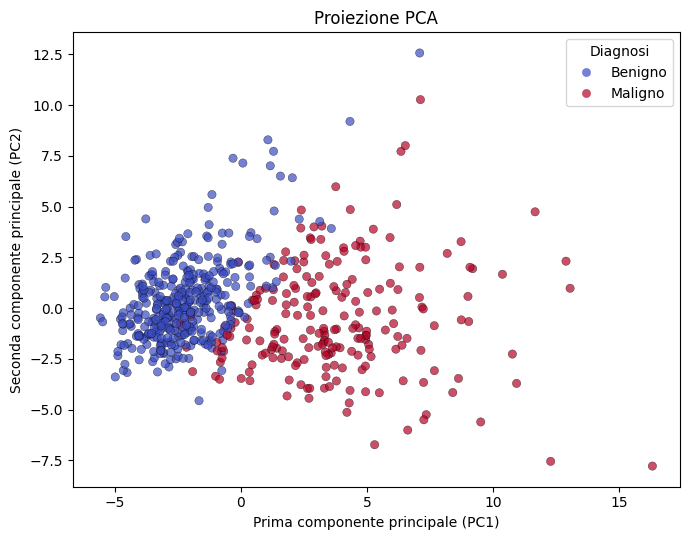

Varianza spiegata dalle prime 2 componenti: 63.24%


In [40]:
X_scaled_eda = StandardScaler().fit_transform(X)

#Proiezione sulle prime due componenti principali
pca_2d = PCA(n_components = 2, random_state = RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled_eda)

fig, ax = plt.subplots(figsize = (7, 5.5))
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c = y, cmap = "coolwarm", alpha = 0.7, edgecolor = "k", linewidth = 0.3)
ax.set_title("Proiezione PCA")
ax.set_xlabel("Prima componente principale (PC1)")
ax.set_ylabel("Seconda componente principale (PC2)")
handles, _ = scatter.legend_elements()
ax.legend(handles, ["Benigno", "Maligno"], title = "Diagnosi")

plt.tight_layout()
plt.show()

print(f"Varianza spiegata dalle prime 2 componenti: {pca_2d.explained_variance_ratio_.sum():.2%}")

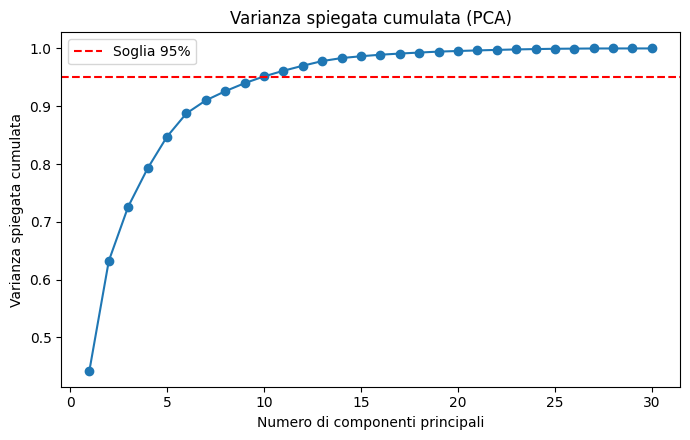

Sono necessarie 10 componenti per spiegare almeno il 95% della varianza


In [41]:
#Curva della varianza spiegata cumulata al crescere del numero di componenti
pca_full = PCA(random_state = RANDOM_STATE).fit(X_scaled_eda)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize = (7, 4.5))
ax.plot(range(1, len(cum_var) + 1), cum_var, marker = "o")
ax.axhline(y = 0.95, color = "red", linestyle = "--", label = "Soglia 95%")
ax.set(title = "Varianza spiegata cumulata (PCA)", xlabel = "Numero di componenti principali", ylabel = "Varianza spiegata cumulata")
ax.legend()

plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cum_var >= 0.95) + 1)
print(f"Sono necessarie {n_components_95} componenti per spiegare almeno il 95% della varianza")

Lo scatter plot mostra due nubi ben distinte ma con una zona di **sovrapposizione** lungo la frontiera, indicando che le sole prime due componenti separano già bene le classi. La sovrapposizione residua giustifica però la presenza di un modello non lineare (SVM-RBF) e di un ensemble (RF). La curva cumulata conferma la **bassa dimensionalità effettiva** indotta dalla multicollinearità.

## Protocollo di valutazione e prevenzione del data leakage

In [42]:
#Suddividiamo il dataset in 80% training e 20% test con stratificazione per mantenere le proporzioni di classe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, stratify = y, random_state = RANDOM_STATE)

print(f"Training set: {X_train.shape} - Test set: {X_test.shape}")
print(f"Proporzione Maligni nel train: {y_train.mean():.2%}")
print(f"Proporzione Maligni nel test:  {y_test.mean():.2%}")

#Strategia di cross validation per il tuning con Stratified 5-Fold
cv_strategy = StratifiedKFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)

Training set: (455, 30) - Test set: (114, 30)
Proporzione Maligni nel train: 37.36%
Proporzione Maligni nel test:  36.84%


In [43]:
#Ogni modello è incapsulato in una Pipeline con StandardScaler a monte così lo scaler viene riadattato solo sul training di ogni fold, eliminando il data leakage.
pipelines = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter = 5000, solver = "liblinear", random_state = RANDOM_STATE))
    ]),
    "LDA": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis())
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel = "rbf", probability = True, random_state = RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(random_state = RANDOM_STATE))
    ])
}

#Griglie di iperparametri (prefisso 'clf__' per riferirsi allo step del classificatore nella pipeline)
param_grids = {
    "Logistic Regression": {
        "clf__C": [0.01, 0.1, 1, 10], #Inverso della regolarizzazione (basso = modello rigido, previene overfitting)
        "clf__penalty": ["l1", "l2"], #Regolarizzazione (L1 azzera le feature, L2 le riduce)
    },
    "LDA": [
        {"clf__solver": ["svd"]}, # Decomposizione (svd per matrici normali, lsqr se si usa lo shrinkage)
        {"clf__solver": ["lsqr"], "clf__shrinkage": [None, "auto", 0.1, 0.5, 0.9]} #Regolarizzazione della covarianza
    ],
    "SVM (RBF)": {
        "clf__C": [0.1, 1, 10, 100], #Slack / Tolleranza agli errori (basso = margine morbido, alto = margine rigido).
        "clf__gamma": ["scale", 0.001, 0.01, 0.1, 1] #Raggio d'azione del singolo punto (basso = influenza globale, alto = "bolle" locali, rischio overfitting).
    },
    "Random Forest": {
        "clf__n_estimators": [50, 100, 200], #Numero di alberi
        "clf__max_depth": [None, 3, 5, 10], #Profondità massima dell'albero
        "clf__min_samples_leaf": [1, 2, 4] #Numero minimo di campioni in una foglia
    }
}

print(f"Pipeline e griglie di iperparametri definite per {len(pipelines)} modelli.")

Pipeline e griglie di iperparametri definite per 4 modelli.


## Tuning degli iperparametri

In [44]:
fitted_models = {}
cv_summary = []

for name in pipelines:
    grid = GridSearchCV(
        estimator = pipelines[name],
        param_grid = param_grids[name],
        scoring = "recall", #Cerchiamo di ottimizzare il recall poiché un FN (paziente malata dichiarata sana) è molto più grave di un FP
        cv = cv_strategy,
        refit = True
    )
    grid.fit(X_train, y_train)
    fitted_models[name] = grid.best_estimator_
    cv_summary.append({
        "Modello": name,
        "Miglior Recall (CV)": round(grid.best_score_, 4),
        "Migliori parametri": grid.best_params_
    })
    print(f"Modello: {name}")
    print(f"- Miglior recall in CV: {grid.best_score_:.4f}")
    print(f"- Parametri ottimali: {grid.best_params_}\n")

Modello: Logistic Regression
- Miglior recall in CV: 0.9588
- Parametri ottimali: {'clf__C': 0.01, 'clf__penalty': 'l1'}

Modello: LDA
- Miglior recall in CV: 0.8941
- Parametri ottimali: {'clf__shrinkage': 'auto', 'clf__solver': 'lsqr'}

Modello: SVM (RBF)
- Miglior recall in CV: 0.9647
- Parametri ottimali: {'clf__C': 10, 'clf__gamma': 'scale'}

Modello: Random Forest
- Miglior recall in CV: 0.9471
- Parametri ottimali: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100}



Ottimizzare solo recall potrebbe premiare un classificatore degenere che predice "Maligno" per tutti (recall = 1 ma precision pessima), per questo motivo le griglie sono volutamente contenute; inoltre, nella valutazione del test set, vengono riportate **sempre** precision e specificity accanto al recall, così da verificare che il *best estimator* selezionato non sia degenere e mantenga un'elevata capacità discriminante complessiva (AUC).

In [45]:
#Valutazione tramite cross validation ripetuta con 5 ripetizioni di una 5-fold stratificata (25 valutazioni per modello)
repeated_cv = RepeatedStratifiedKFold(n_splits = 5, n_repeats = 5, random_state = RANDOM_STATE)

#Metriche raccolte ad ogni fold
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

repeated_summary = []
for name, model in fitted_models.items():
    # Si valutano i modelli già ottimizzati
    scores = cross_validate(model, X_train, y_train, cv = repeated_cv, scoring = scoring, n_jobs = -1)
    row = {"Modello": name}
    
    for metric in scoring:
        valori = scores[f"test_{metric}"]
        row[f"{metric} (media)"] = round(valori.mean(), 4)
        row[f"{metric} (std)"] = round(valori.std(), 4)
        
    repeated_summary.append(row)

repeated_cv_df = pd.DataFrame(repeated_summary).set_index("Modello")
repeated_cv_df

,accuracy (media),accuracy (std),precision (media),precision (std),recall (media),recall (std),f1 (media),f1 (std),roc_auc (media),roc_auc (std)
Modello,,,,,,,,,,
Logistic Regression,0.9279,0.0312,0.8698,0.0533,0.9529,0.0300,0.9088,0.0375,0.9810,0.0136
LDA,0.9569,0.0176,0.9961,0.0105,0.8882,0.0456,0.9385,0.0262,0.9923,0.0072
SVM (RBF),0.9767,0.0133,0.9722,0.0249,0.9659,0.0215,0.9688,0.0177,0.9931,0.0069
Random Forest,0.9569,0.0213,0.9559,0.0392,0.9294,0.0432,0.9415,0.0289,0.9887,0.0067


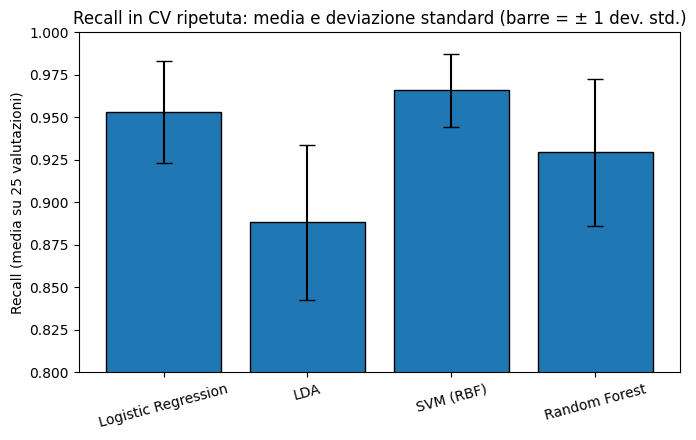

In [46]:
#Grafico a barre del recall medio con deviazione standard per i 4 modelli
fig, ax = plt.subplots(figsize = (7, 4.5))
nomi = list(repeated_cv_df.index)
medie = repeated_cv_df["recall (media)"].values
devstd = repeated_cv_df["recall (std)"].values

ax.bar(nomi, medie, yerr = devstd, capsize = 6, edgecolor = "black")
ax.set(title = "Recall in CV ripetuta: media e deviazione standard (barre = ± 1 dev. std.)", ylabel = "Recall (media su 25 valutazioni)", ylim = (0.80, 1.0))
ax.tick_params(axis = "x", rotation = 15)

plt.tight_layout()
plt.show()

## Validation curve e lettura bias-varianza

In [47]:
#Funzione di supporto per tracciare una validation curve (score di training vs validazione)
#Training alto e validazione bassa -> OVERFITTING (alta varianza); entrambi bassi -> UNDERFITTING (alto bias)
def plot_validation_curve(pipeline, param_name, param_range, title, log_scale = True):
    train_scores, val_scores = validation_curve(
        pipeline, X_train, y_train,
        param_name = param_name, param_range = param_range,
        scoring = "recall", cv = cv_strategy
    )

    train_mean = np.mean(train_scores, axis = 1)
    train_std = np.std(train_scores, axis = 1)
    val_mean = np.mean(val_scores, axis = 1)
    val_std = np.std(val_scores, axis = 1)

    fig, ax = plt.subplots(figsize = (7, 4.5))
    ax.plot(param_range, train_mean, marker = "o", label = "Recall di training", color = "darkorange")
    ax.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha = 0.15, color = "darkorange")
    ax.plot(param_range, val_mean, marker = "s", label = "Recall di validazione (CV)", color = "navy")
    ax.fill_between(param_range, val_mean - val_std, val_mean + val_std, alpha = 0.15, color = "navy")
    if log_scale: ax.set_xscale("log")
    ax.set(xlabel = param_name, ylabel = "Recall", title = title)
    ax.legend(loc = "best")
    
    plt.tight_layout()
    plt.show()

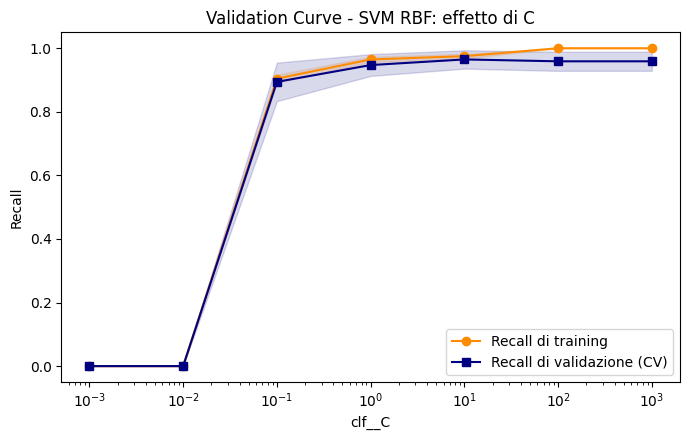

In [48]:
#Validation curve per la SVM al variare di C (a gamma fissato sul valore 'scale')
#C governa il peso delle slack variables: C grande -> margine stretto, rischio overfitting
svm_pipe_for_curve = Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel = "rbf", gamma = "scale", probability = False, random_state = RANDOM_STATE))])
plot_validation_curve(svm_pipe_for_curve, "clf__C", [0.001, 0.01, 0.1, 1, 10, 100, 1000], "Validation Curve - SVM RBF: effetto di C")

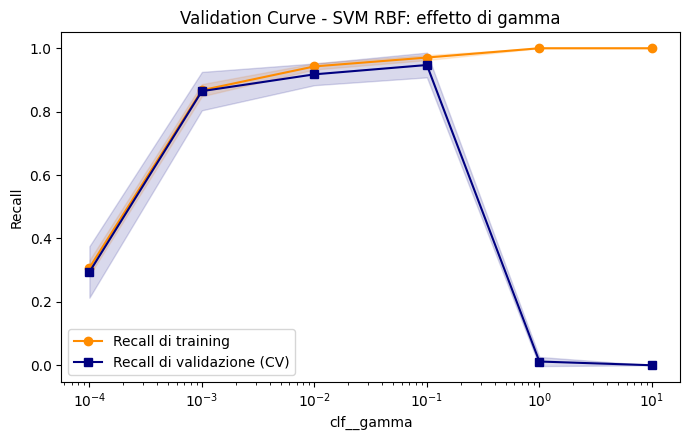

In [49]:
#Validation curve per la SVM al variare di gamma (a C fissato a 1)
#Gamma controlla l'ampiezza del kernel RBF: gamma grande -> frontiere molto flessibili, rischio overfitting
svm_pipe_gamma = Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel = "rbf", C = 1, probability = False, random_state = RANDOM_STATE))])
plot_validation_curve(svm_pipe_gamma, "clf__gamma", [1e-4, 1e-3, 1e-2, 1e-1, 1, 10], "Validation Curve - SVM RBF: effetto di gamma")

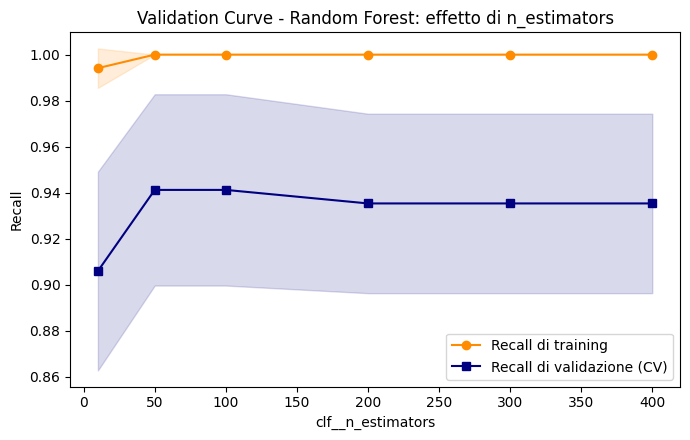

In [50]:
#Validation curve per la Random Forest al variare del numero di alberi
#Nel bagging, aumentare il numero di alberi riduce la varianza e tende a stabilizzare le performance
rf_pipe_n = Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(random_state = RANDOM_STATE))])
plot_validation_curve(rf_pipe_n, "clf__n_estimators", [10, 50, 100, 200, 300, 400], "Validation Curve - Random Forest: effetto di n_estimators", log_scale = False)

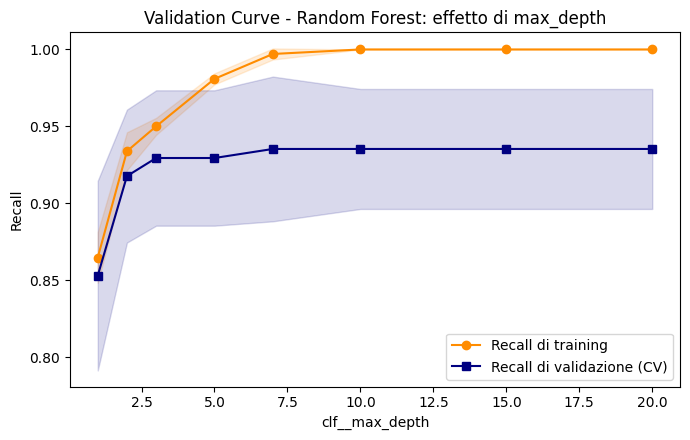

In [51]:
#Validation curve per la Random Forest al variare della profondita massima degli alberi
#max_depth governa la complessita del singolo albero: alta -> alta varianza (Lez. 32)
rf_pipe_depth = Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(n_estimators = 200, random_state = RANDOM_STATE))])
plot_validation_curve(rf_pipe_depth, "clf__max_depth", [1, 2, 3, 5, 7, 10, 15, 20], "Validation Curve - Random Forest: effetto di max_depth", log_scale = False)

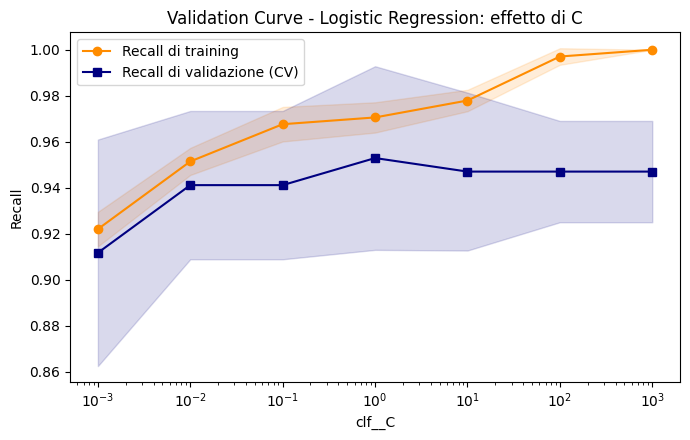

In [52]:
#Validation curve per la Regressione Logistica al variare del parametro di regolarizzazione C
#C è l'inverso della forza di regolarizzazione: C piccolo -> forte regolarizzazione, rischio underfitting
logreg_pipe_c = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter = 5000, solver = "liblinear", random_state = RANDOM_STATE))])
plot_validation_curve(logreg_pipe_c, "clf__C", [0.001, 0.01, 0.1, 1, 10, 100, 1000], "Validation Curve - Logistic Regression: effetto di C")

## Valutazione sul test set held-out e confronto

In [53]:
#Funzione per la specificita (True Negative Rate)
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

#Valutazione di ogni best estimator sul TEST SET held-out (mai visto durante il tuning)
test_summary = []
predictions = {}
probabilities = {}

for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    predictions[name] = y_pred
    probabilities[name] = y_proba
    
    test_summary.append({
        "Modello": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall (Sensibilita)": recall_score(y_test, y_pred),
        "Specificity": specificity_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    })

test_results_df = pd.DataFrame(test_summary).set_index("Modello").round(4)
test_results_df

,Accuracy,Precision,Recall (Sensibilita),Specificity,F1-score,AUC
Modello,,,,,,
Logistic Regression,0.9737,0.9333,1.0000,0.9583,0.9655,0.9960
LDA,0.9649,1.0000,0.9048,1.0000,0.9500,0.9983
SVM (RBF),0.9737,1.0000,0.9286,1.0000,0.9630,0.9927
Random Forest,0.9737,1.0000,0.9286,1.0000,0.9630,0.9950


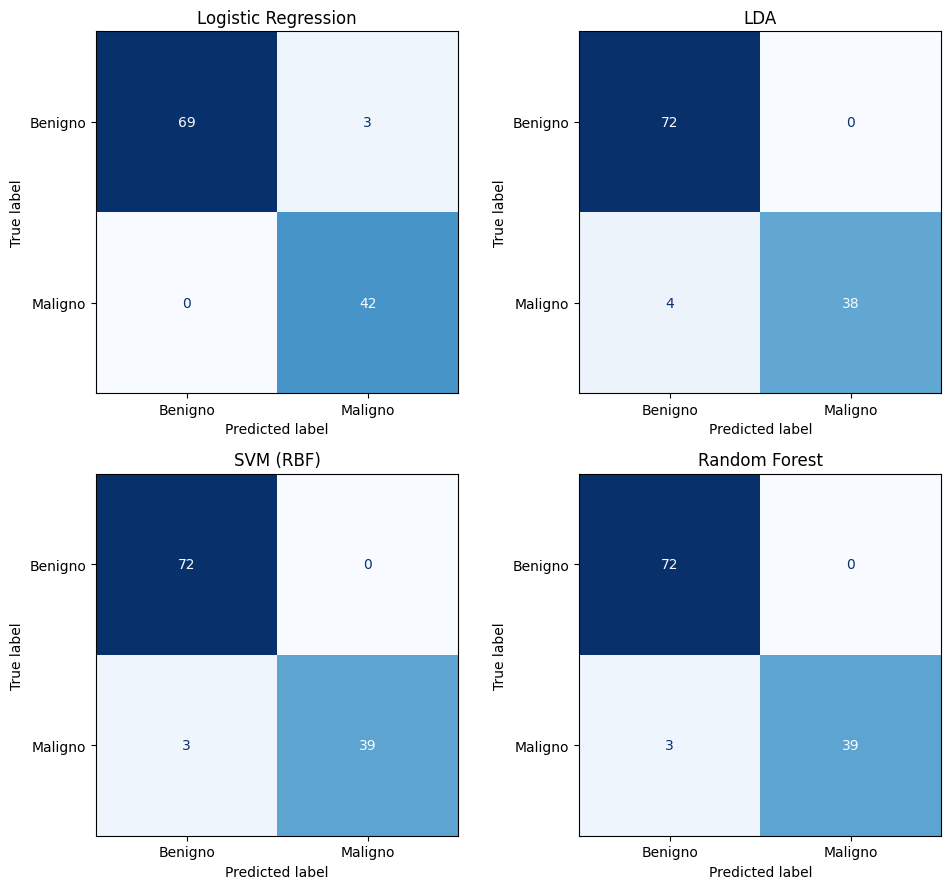

In [54]:
#Matrici di confusione dei quattro modelli sul test set
fig, axes = plt.subplots(2, 2, figsize = (10, 9))

for ax, name in zip(axes.ravel(), fitted_models):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Benigno", "Maligno"])
    disp.plot(ax = ax, cmap = "Blues", colorbar = False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

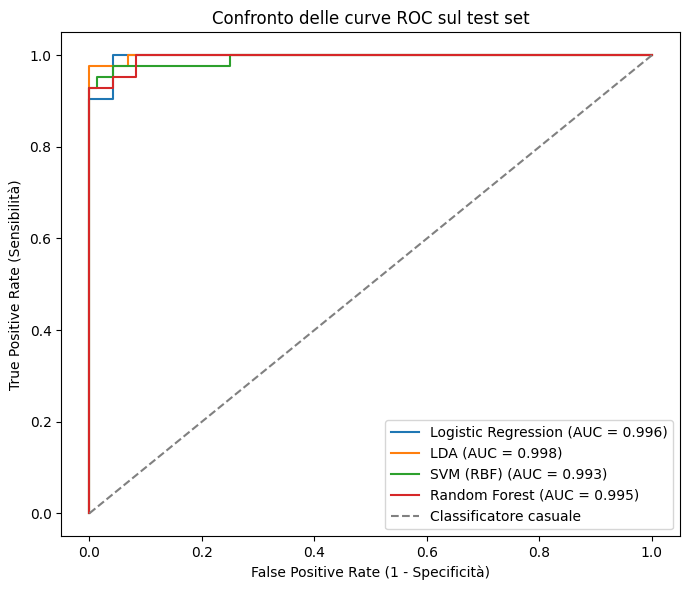

In [55]:
#Curve ROC sovrapposte: l'AUC misura la bontà complessiva del classificatore.
fig, ax = plt.subplots(figsize = (7, 6))

for name, proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label = f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle = "--", color = "grey", label = "Classificatore casuale")
ax.set(xlabel = "False Positive Rate (1 - Specificità)", ylabel = "True Positive Rate (Sensibilità)", title = "Confronto delle curve ROC sul test set")
ax.legend(loc = "lower right")

plt.tight_layout()
plt.show()

Analizzando la tabella e le ROC è normale aspettarsi che tutti i modelli raggiungano AUC molto elevate, con differenze sottili sul piano recall/precision. E' bene notare che i modelli lineari restano competitivi proprio perché la frontiera è quasi lineare; la SVM-RBF e la RF offrono la flessibilità per recuperare gli esempi nella zona di sovrapposizione. La scelta finale dipende dall'obiettivo: massimizzare la sensibilità mantenendo accettabile il tasso di falsi positivi.

## Analisi della soglia decisionale sulla ROC

In [56]:
#Selezione del modello con AUC piu elevata per l'analisi della soglia
auc_per_model = {}
for name, proba in probabilities.items():
    fpr_m, tpr_m, _ = roc_curve(y_test, proba)
    auc_per_model[name] = auc(fpr_m, tpr_m)
    
best_auc_name = max(auc_per_model, key = auc_per_model.get)
print(f"Modello con AUC migliore: {best_auc_name} (AUC = {auc_per_model[best_auc_name]:.3f})")

y_proba_best = probabilities[best_auc_name]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)

#Criterio 1: indice J di Youden (massimizza TPR - FPR), punto operativo bilanciato
youden_j = tpr - fpr
idx_youden = int(np.argmax(youden_j))
thr_youden = thresholds[idx_youden]

#Criterio 2: ottica clinica - soglia piu alta che garantisce sensibilita molto elevata (TPR >= 0.99)
target_tpr = 0.99
valid_idx = np.where(tpr >= target_tpr)[0]
if len(valid_idx) == 0:
    idx_clinical = idx_youden
else:
    idx_clinical = int(valid_idx[np.argmin(fpr[valid_idx])])
thr_clinical = thresholds[idx_clinical]

print("\nSoglia di default: 0.50")
print(f"Soglia di Youden: {thr_youden:.4f} (TPR = {tpr[idx_youden]:.3f}, FPR = {fpr[idx_youden]:.3f})")
print(f"Soglia clinica (TPR >= {target_tpr:.2f}): {thr_clinical:.4f} (TPR = {tpr[idx_clinical]:.3f}, FPR = {fpr[idx_clinical]:.3f})")

Modello con AUC migliore: LDA (AUC = 0.998)

Soglia di default: 0.50
Soglia di Youden: 0.4308 (TPR = 0.976, FPR = 0.000)
Soglia clinica (TPR >= 0.99): 0.0443 (TPR = 1.000, FPR = 0.069)


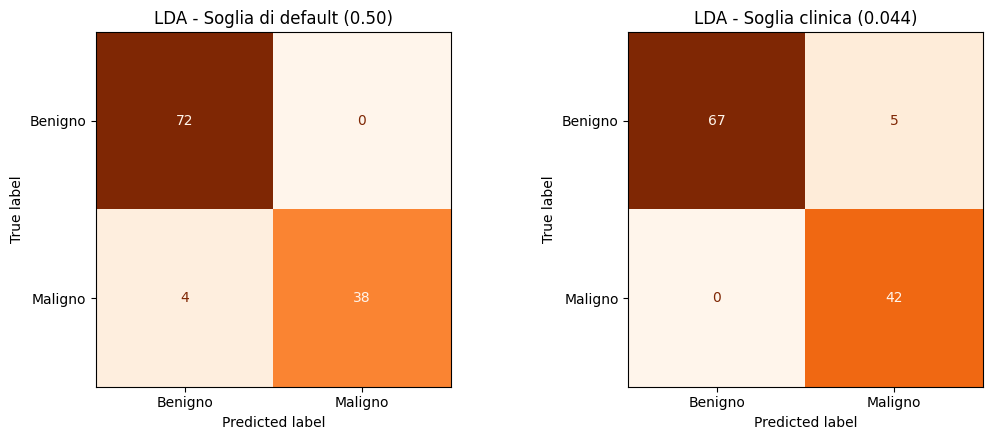

Falsi Negativi -> default: 4 | clinica: 0
Falsi Positivi -> default: 0 | clinica: 5


In [57]:
#Confronto delle matrici di confusione alla soglia di default (0.5) e alla soglia clinica
def predict_with_threshold(proba, threshold): return (proba >= threshold).astype(int)

y_pred_default = predict_with_threshold(y_proba_best, 0.5)
y_pred_clinical = predict_with_threshold(y_proba_best, thr_clinical)

#Calcolo matrici a monte per evitare ricalcoli
cm_default = confusion_matrix(y_test, y_pred_default)
cm_clinical = confusion_matrix(y_test, y_pred_clinical)
cms = [cm_default, cm_clinical]

fig, axes = plt.subplots(1, 2, figsize = (11, 4.5))
titoli = ["Soglia di default (0.50)", f"Soglia clinica ({thr_clinical:.3f})"]

for ax, cm, titolo in zip(axes, cms, titoli):
    ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Benigno", "Maligno"]).plot(ax = ax, cmap = "Oranges", colorbar = False)
    ax.set_title(f"{best_auc_name} - {titolo}")

plt.tight_layout()
plt.show()

fn_default = int(cm_default[1, 0])
fn_clinical = int(cm_clinical[1, 0])
fp_default = int(cm_default[0, 1])
fp_clinical = int(cm_clinical[0, 1])

print(f"Falsi Negativi -> default: {fn_default} | clinica: {fn_clinical}")
print(f"Falsi Positivi -> default: {fp_default} | clinica: {fp_clinical}")

Abbassando la soglia decisionale aumentiamo la sensibilità: tipicamente i falsi negativi si riducono (idealmente a zero) al prezzo di qualche falso positivo in più.

Clinicamente parlando è la scelta corretta: un falso positivo comporta accertamenti aggiuntivi, un falso negativo può comportare una diagnosi mancata. La soglia ottimale non è un dato puramente statistico ma una decisione che incorpora i costi differenziali degli errori.

## Interpretabilità vs Spiegabilità

### Interpretabilità intrinseca: i coefficienti della Logistic Regression

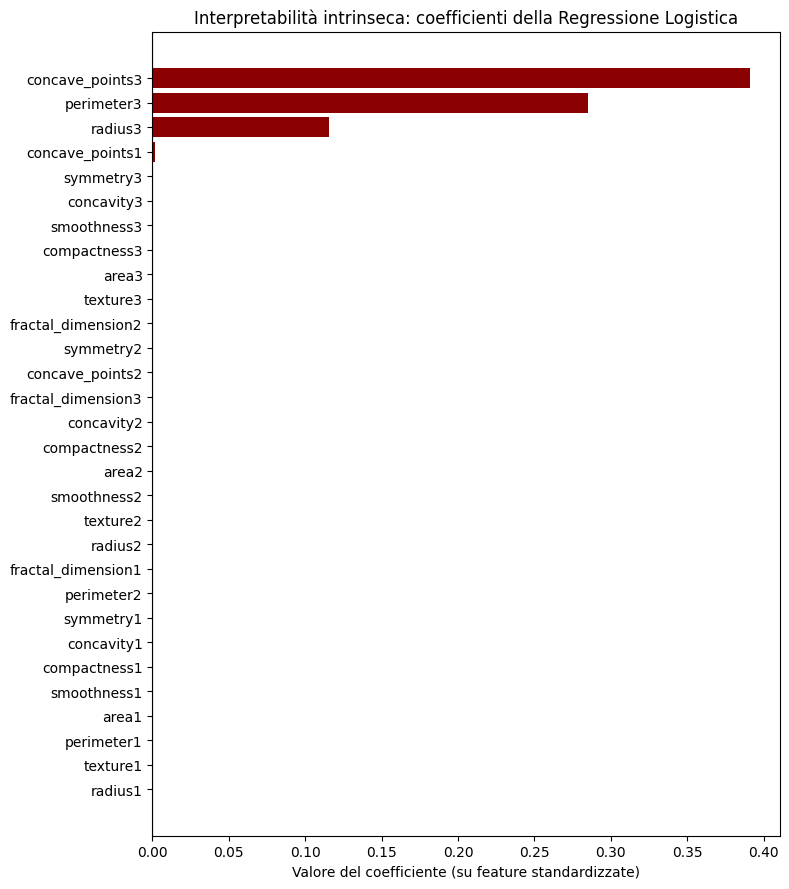

Top 5 feature che aumentano gli odds di malignità (odds ratio):
concave_points3    1.479
perimeter3         1.330
radius3            1.123
concave_points1    1.002
radius1            1.000


In [ ]:
#Interpretabilità "by design" tramite i coefficienti della Regressione Logistica
logreg_model = fitted_models["Logistic Regression"].named_steps["clf"]
coef = logreg_model.coef_[0]
coef_series = pd.Series(coef, index = X.columns).sort_values()

fig, ax = plt.subplots(figsize = (8, 9))
colors = ["navy" if v < 0 else "darkred" for v in coef_series.values]

ax.barh(coef_series.index, coef_series.values, color = colors)
ax.set(xlabel = "Valore del coefficiente (su feature standardizzate)", title = "Interpretabilità intrinseca: coefficienti della Regressione Logistica")
ax.axvline(x = 0, color = "black", linewidth = 0.8)

plt.tight_layout()
plt.show()

#Lettura come odds ratio: exp(coef) è il fattore moltiplicativo sugli odds di malignità
odds_ratios = np.exp(coef_series).sort_values(ascending = False)
print(f"Top 5 feature che aumentano gli odds di malignità (odds ratio):\n{odds_ratios.head(5).round(3).to_string()}")

### Spiegabilità tramite feature importance e SHAP sulla Random Forest

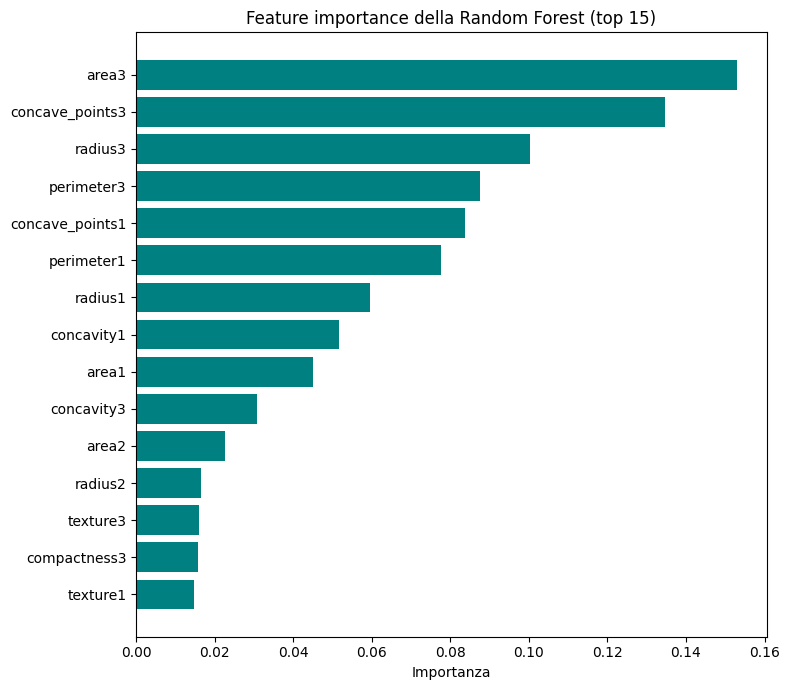

In [61]:
#Spiegabilità tramite importanza delle feature della Random Forest
rf_model = fitted_models["Random Forest"].named_steps["clf"]
importances = pd.Series(rf_model.feature_importances_, index = X.columns).sort_values(ascending = False)

top_imp = importances.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize = (8, 7))
ax.barh(top_imp.index, top_imp.values, color = "teal")
ax.set(xlabel = "Importanza", title = "Feature importance della Random Forest (top 15)")

plt.tight_layout()
plt.show()

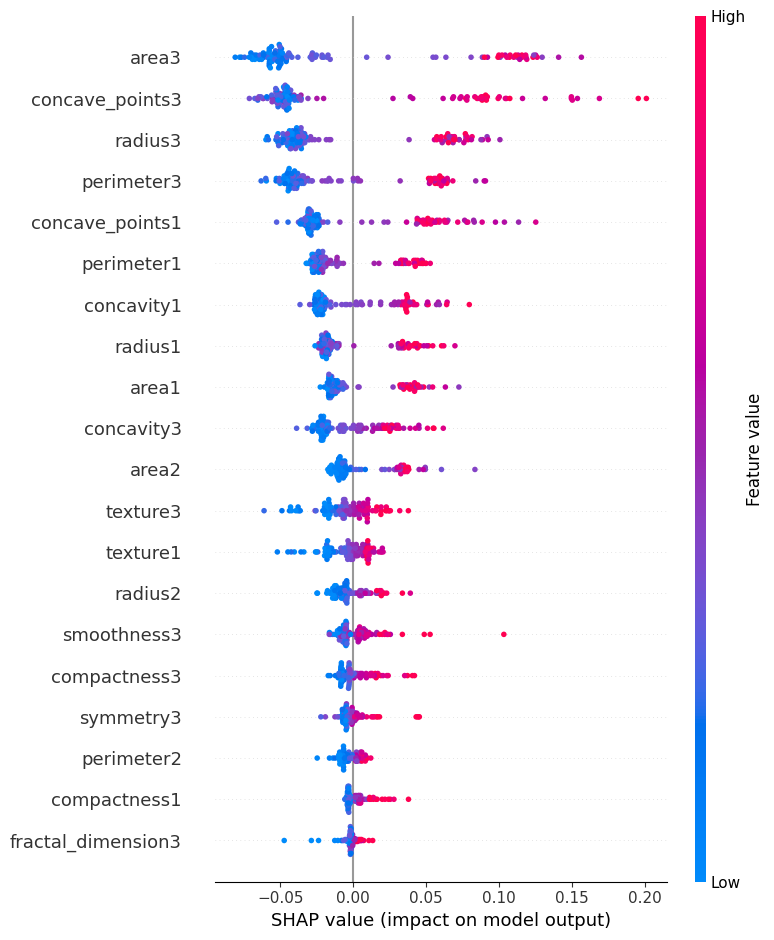

In [ ]:
#Spiegabilità tramite valori di SHAP sulla Random Forest (TreeExplainer)
rf_pipeline = fitted_models["Random Forest"]
scaler_rf = rf_pipeline.named_steps["scaler"]
X_test_scaled = scaler_rf.transform(X_test)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
elif np.ndim(shap_values) == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

shap.summary_plot(shap_values_pos, X_test_scaled, feature_names = list(X.columns), show = True)

La Logistic Regression *è* la sua spiegazione: il vettore dei coefficienti descrive in modo esaustivo e trasparente la regola decisionale. La Random Forest, al contrario, è un aggregato di centinaia di alberi: nessun parametro singolo è leggibile, e dobbiamo ricorrere a strumenti *post-hoc* — la *feature importance* e *SHAP*. È istruttivo verificare la **coerenza** tra le classifiche: tipicamente le feature *worst* legate a dimensione e concavità (es. `radius3`, `concave_points_3`, `perimeter_3`) emergono come dominanti in *tutti e tre* gli approcci, il che rafforza la fiducia nel modello e ne consente una lettura clinicamente sensata.

## Discussione critica e conclusioni

Su WDBC tutti e quattro i modelli raggiungono performance elevate, conferma del fatto che il problema è ben strutturato e quasi linearmente separabile (evidenza già emersa dalla proiezione PCA). Sono emerse delle sfumature rilevanti:

- I **modelli lineari** (Logistic Regression, LDA) offrono il miglior rapporto tra performance, semplicità e interpretabilità intrinseca: difficilmente overfittano e forniscono coefficienti leggibili clinicamente. La loro competitività è la prova empirica della quasi-linearità della frontiera.
- La **SVM-RBF** sfrutta il *kernel trick* per modellare la curvatura nella zona di sovrapposizione; la sua robustezza dipende criticamente dal tuning di `C` e `gamma`, come reso evidente dalle validation curve.
- La **Random Forest** offre flessibilità e una naturale stima dell'importanza delle feature, al prezzo dell'interpretabilità diretta.

Avendo ottimizzato il **recall**, la lettura privilegiata è la minimizzazione dei falsi negativi. L'analisi della soglia ha mostrato come sia possibile spingere ulteriormente la sensibilità verso 1, accettando un modesto incremento di falsi positivi - un compromesso clinicamente accettabile e, anzi, auspicabile in fase di screening.